In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from qiskit.circuit import QuantumCircuit
from qiskit_aer import AerSimulator
from Preprocess import preprocess_data

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [5]:
data_orig = pd.read_csv("../filtered_features.csv")
filtered_time = pd.read_csv("../filtered_event_times.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 4)
Next slips shape (4717, 12)
orig shape (4942, 12)


/Users/noah/repos/Icequake-QRC-/Classical/Preprocess.py:58: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



ValueError: Found input variables with inconsistent numbers of samples: [4717, 4897]

In [6]:
# QRC Configuration
QRC_CONFIG = {
    "num_layers": 3,
    "shots": 1024,
    "n_iterations": 10,
    "top_k": 3,
    "correlation_threshold": 0.0,  # 0.0 = keep all features
    "random_seed": 42,
}

# Change this to swap the classical model: "Ridge", "XGBoost", or "CatBoost"
CLASSICAL_MODEL_NAME = "XGBoost"

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)

QRC Config: {'num_layers': 3, 'shots': 1024, 'n_iterations': 10, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [4]:
def select_features_by_correlation(X_train, y_train, feature_cols, threshold):
    """Keep features whose |Pearson correlation| with the target >= threshold."""
    if threshold <= 0.0:
        return list(range(len(feature_cols))), feature_cols

    selected_idx = []
    selected_names = []
    for i, col in enumerate(feature_cols):
        corr = np.abs(np.corrcoef(X_train[:, i], y_train)[0, 1])
        if corr >= threshold:
            selected_idx.append(i)
            selected_names.append(col)
    return selected_idx, selected_names


selected_idx, selected_features = select_features_by_correlation(
    X_train, y_train, feature_cols, QRC_CONFIG["correlation_threshold"]
)

X_train_sel = X_train[:, selected_idx]
X_val_sel = X_val[:, selected_idx]
X_test_sel = X_test[:, selected_idx]

n_qubits = len(selected_features)
n_states = 2 ** n_qubits

print(f"Selected features ({n_qubits}): {selected_features}")
print(f"Probability vector dimension: {n_states}")

NameError: name 'X_train' is not defined

In [21]:
def scale_to_pi_range(X_train, X_val, X_test):
    """Min-max scale features to [0, pi]. Fit on train only, clip val/test."""
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0  # avoid division by zero for constant features

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)
print(f"Quantum-scaled train range: [{X_train_q.min():.4f}, {X_train_q.max():.4f}]")

Quantum-scaled train range: [0.0000, 3.1416]


In [1]:
def generate_random_angles(num_layers, n_qubits, rng):
    """Generate random rotation angles for the reservoir layers.
    Returns array of shape (num_layers, n_qubits, 3) for Rx, Rz, Ry."""
    return rng.uniform(0, 2 * np.pi, size=(num_layers, n_qubits, 3))


def build_reservoir_circuit(data_sample, random_angles, num_layers, n_qubits):
    """Build a quantum reservoir circuit for a single data sample.

    Encoding layer: Ry(data[i]) on qubit i
    Reservoir (per layer): Rx, Rz, Ry with random angles + linear CNOT chain
    """
    qc = QuantumCircuit(n_qubits)

    # Encoding layer
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)

    qc.barrier()

    # Reservoir layers
    for layer in range(num_layers):
        for i in range(n_qubits):
            qc.rx(float(random_angles[layer, i, 0]), i)
            qc.rz(float(random_angles[layer, i, 1]), i)
            qc.ry(float(random_angles[layer, i, 2]), i)
        # Linear CNOT chain for entanglement
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        # qc.cx(0, n_qubits)
        qc.barrier()

    qc.measure_all()
    return qc


# Visual check: print a sample circuit
sample_rng = np.random.default_rng(0)
sample_angles = generate_random_angles(QRC_CONFIG["num_layers"], n_qubits, sample_rng)
sample_qc = build_reservoir_circuit(X_train_q[0], sample_angles, QRC_CONFIG["num_layers"], n_qubits)
print(sample_qc.draw(output="text"))

NameError: name 'np' is not defined

In [23]:
def run_quantum_reservoir(X_data, random_angles, num_layers, n_qubits, shots, batch_size=500):
    """Execute quantum reservoir circuits and return probability matrix.

    Parameters
    ----------
    X_data : array of shape (m, n_qubits), quantum-scaled features
    random_angles : array of shape (num_layers, n_qubits, 3)
    num_layers, n_qubits, shots : reservoir parameters
    batch_size : number of circuits per Aer batch

    Returns
    -------
    prob_matrix : array of shape (m, 2^n_qubits)
    """
    m = X_data.shape[0]
    n_states = 2 ** n_qubits
    prob_matrix = np.zeros((m, n_states))

    simulator = AerSimulator()

    # Build all circuits
    circuits = []
    for i in range(m):
        qc = build_reservoir_circuit(X_data[i], random_angles, num_layers, n_qubits)
        circuits.append(qc)

    # Execute in batches
    for start in range(0, m, batch_size):
        end = min(start + batch_size, m)
        batch = circuits[start:end]
        result = simulator.run(batch, shots=shots).result()

        counts_list = result.get_counts()
        # get_counts() returns a dict for single circuit, list for multiple
        if isinstance(counts_list, dict):
            counts_list = [counts_list]

        for j, counts in enumerate(counts_list):
            for bitstring, count in counts.items():
                idx = int(bitstring.replace(" ", ""), 2)
                prob_matrix[start + j, idx] = count / shots

    return prob_matrix


# Quick shape check on a small subset
test_angles = generate_random_angles(QRC_CONFIG["num_layers"], n_qubits, np.random.default_rng(0))
test_prob = run_quantum_reservoir(X_train_q[:3], test_angles, QRC_CONFIG["num_layers"], n_qubits, QRC_CONFIG["shots"])
print(f"Probability matrix shape: {test_prob.shape}")
print(f"Row sums (should be ~1.0): {test_prob.sum(axis=1)}")

Probability matrix shape: (3, 64)
Row sums (should be ~1.0): [1. 1. 1.]


In [24]:
def get_model_registry():
    """Return a dict of classical models, each with Optuna search space,
    build function, fit function, and SHAP explainer type.

    To add a new model: add a new key with the same structure.
    """
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 5),
                "subsample": trial.suggest_float("subsample", 0.6, 0.9),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
            },
            "fixed_params": {
                "objective": "reg:squarederror",
                "n_estimators": 1000,
                "random_state": 42,
            },
            "build_fn": lambda params: XGBRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=[(Xv, yv)], verbose=False
            ),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth": trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations": 100,
                "loss_function": "RMSE",
                "eval_metric": "RMSE",
                "random_seed": 42,
                "verbose": False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=(Xv, yv), use_best_model=True
            ),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")

Available models: ['Ridge', 'XGBoost', 'CatBoost']
Using: XGBoost


In [25]:
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    """Run one QRC iteration: quantum reservoir + Optuna-tuned classical model."""
    num_layers = config["num_layers"]
    shots = config["shots"]
    seed = config["random_seed"] + iteration_idx

    rng = np.random.default_rng(seed)
    random_angles = generate_random_angles(num_layers, n_qubits, rng)

    # Run quantum reservoir on all splits
    P_train = run_quantum_reservoir(X_train_q, random_angles, num_layers, n_qubits, shots)
    P_val = run_quantum_reservoir(X_val_q, random_angles, num_layers, n_qubits, shots)
    P_test = run_quantum_reservoir(X_test_q, random_angles, num_layers, n_qubits, shots)

    # Optuna hyperparameter tuning
    entry = registry[model_name]

    def objective(trial):
        tuned = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model = entry["build_fn"](params)
        entry["fit_fn"](model, P_train, y_train, P_val, y_val)
        preds = model.predict(P_val)
        return root_mean_squared_error(y_val, preds)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=30)

    # Train final model with best params
    best_tuned = entry["optuna_fn"](study.best_trial)
    best_params = {**entry["fixed_params"], **best_tuned}
    model = entry["build_fn"](best_params)
    entry["fit_fn"](model, P_train, y_train, P_val, y_val)

    # Evaluate
    val_pred = model.predict(P_val)
    test_pred = model.predict(P_test)

    val_r2 = r2_score(y_val, val_pred)
    val_rmse = root_mean_squared_error(y_val, val_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    return {
        "iteration": iteration_idx,
        "val_r2": val_r2,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_pred": test_pred,
        "best_params": best_params,
        "model": model,
        "P_train": P_train,
        "P_val": P_val,
        "P_test": P_test,
    }

In [26]:
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    """Run n_iterations of QRC, ensemble top-k by val R-squared."""
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i+1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i, X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(f"\tVal R²: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | Test RMSE: {res['test_rmse']:.2f} | Test MAE: {res['test_mae']:.2f}")
        results.append(res)

    # Select top-k by validation R-squared
    top_k = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_r2"], reverse=True)
    top_results = sorted_results[:top_k]
    top_indices = [r["iteration"] for r in top_results]

    print(f"\nTop-{top_k} iterations (by val R²): {[i+1 for i in top_indices]}")

    # Ensemble: average test predictions of top-k
    ensemble_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    ensemble_rmse = root_mean_squared_error(y_test, ensemble_pred)
    ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
    ensemble_r2 = r2_score(y_test, ensemble_pred)

    print(f"\nEnsemble Test RMSE: {ensemble_rmse:.2f}")
    print(f"Ensemble Test MAE:  {ensemble_mae:.2f}")
    print(f"Ensemble Test R²:   {ensemble_r2:.4f}")

    return results, ensemble_pred, top_indices


# ── Run the full pipeline ──
all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG, CLASSICAL_MODEL_NAME, registry,
)


── Iteration 1/10 ──
  Val R²: -0.0219 | Val RMSE: 20274.02 | Test RMSE: 26037.94 | Test MAE: 22614.08

── Iteration 2/10 ──
  Val R²: -0.0291 | Val RMSE: 20345.14 | Test RMSE: 26092.54 | Test MAE: 22635.63

── Iteration 3/10 ──
  Val R²: -0.0388 | Val RMSE: 20441.44 | Test RMSE: 26049.59 | Test MAE: 22610.53

── Iteration 4/10 ──
  Val R²: -0.0291 | Val RMSE: 20345.07 | Test RMSE: 26197.73 | Test MAE: 22759.24

── Iteration 5/10 ──
  Val R²: -0.0109 | Val RMSE: 20164.66 | Test RMSE: 26065.95 | Test MAE: 22574.21

── Iteration 6/10 ──
  Val R²: -0.0272 | Val RMSE: 20326.93 | Test RMSE: 25979.03 | Test MAE: 22466.71

── Iteration 7/10 ──
  Val R²: -0.0305 | Val RMSE: 20358.83 | Test RMSE: 25974.24 | Test MAE: 22534.22

── Iteration 8/10 ──
  Val R²: -0.0237 | Val RMSE: 20291.74 | Test RMSE: 26085.72 | Test MAE: 22561.20

── Iteration 9/10 ──
  Val R²: -0.0230 | Val RMSE: 20285.58 | Test RMSE: 26029.85 | Test MAE: 22505.36

── Iteration 10/10 ──
  Val R²: -0.0267 | Val RMSE: 20321.42 | 

In [27]:
# ── Results Summary Table ──
rows = []
for r in all_results:
    rows.append({
        "Iteration": r["iteration"] + 1,
        "Val R²": f"{r['val_r2']:.4f}",
        "Val RMSE": f"{r['val_rmse']:.2f}",
        "Test RMSE": f"{r['test_rmse']:.2f}",
        "Test MAE": f"{r['test_mae']:.2f}",
        "Top-k": "*" if r["iteration"] in top_indices else "",
    })

ensemble_rmse = root_mean_squared_error(y_test, ensemble_pred)
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_r2 = r2_score(y_test, ensemble_pred)
rows.append({
    "Iteration": "Ensemble",
    "Val R²": "-",
    "Val RMSE": "-",
    "Test RMSE": f"{ensemble_rmse:.2f}",
    "Test MAE": f"{ensemble_mae:.2f}",
    "Top-k": "**",
})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

Iteration  Val R² Val RMSE Test RMSE Test MAE Top-k
        1 -0.0219 20274.02  26037.94 22614.08     *
        2 -0.0291 20345.14  26092.54 22635.63      
        3 -0.0388 20441.44  26049.59 22610.53      
        4 -0.0291 20345.07  26197.73 22759.24      
        5 -0.0109 20164.66  26065.95 22574.21     *
        6 -0.0272 20326.93  25979.03 22466.71      
        7 -0.0305 20358.83  25974.24 22534.22      
        8 -0.0237 20291.74  26085.72 22561.20      
        9 -0.0230 20285.58  26029.85 22505.36     *
       10 -0.0267 20321.42  25995.12 22533.48      
 Ensemble       -        -  25949.47 22522.39    **


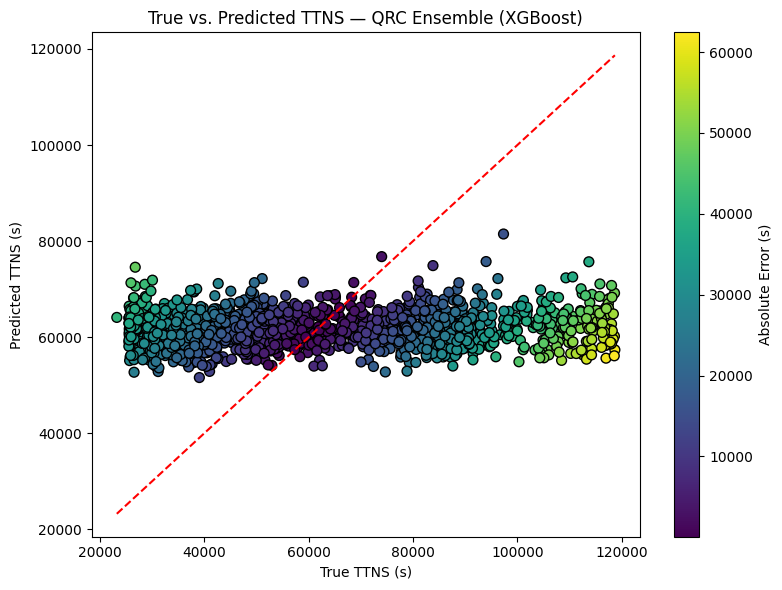

In [28]:
# ── Scatter Plot: Predicted vs Actual (Ensemble) ──
y_test_arr = np.asarray(y_test)
absolute_error = np.abs(ensemble_pred - y_test_arr)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_arr, ensemble_pred, c=absolute_error, cmap="viridis", s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_arr), max(y_test_arr)], [min(y_test_arr), max(y_test_arr)], "r--")
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title(f"True vs. Predicted TTNS — QRC Ensemble ({CLASSICAL_MODEL_NAME})")
plt.tight_layout()
plt.show()

Top-20 most important quantum states (Iteration 5):
000111    781.296423
110101    482.030420
000010    477.243407
111101    376.893813
010010    367.709884
110010    366.555415
100100    361.248071
111100    337.872582
000001    326.851591
100001    326.400483
001000    320.916903
000110    303.811864
000101    286.993797
001001    279.795213
011110    269.477142
100110    267.885862
110100    266.812237
011101    258.564440
110011    251.210188
010000    250.401240
dtype: float64


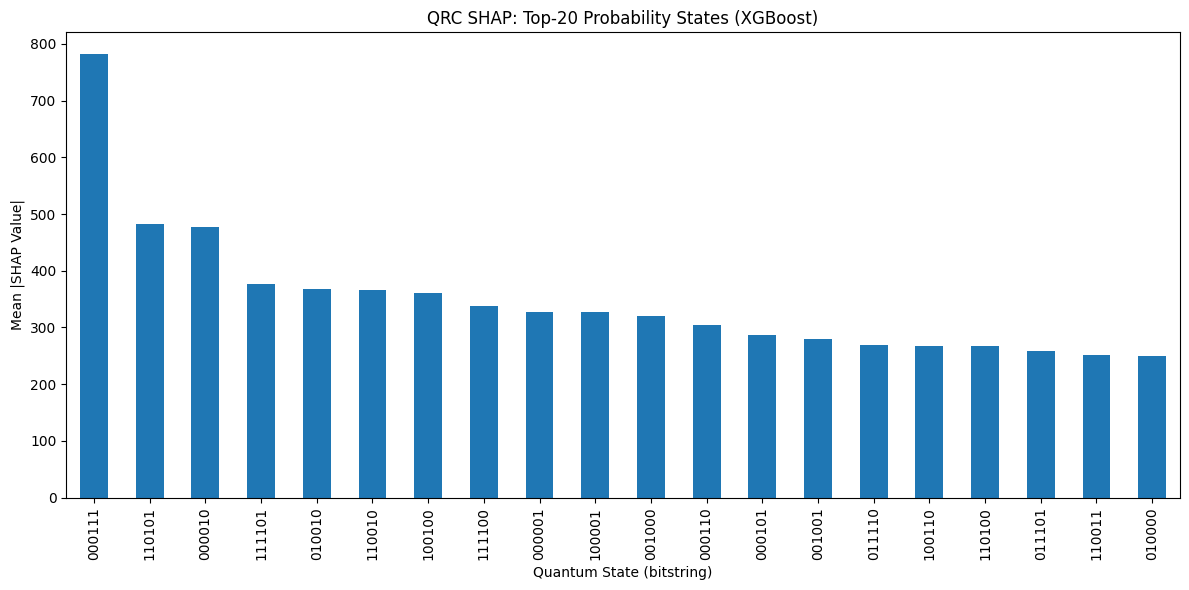

In [29]:
# ── SHAP Analysis on Best Iteration ──
best_result = sorted(all_results, key=lambda r: r["val_r2"], reverse=True)[0]
best_model = best_result["model"]
P_test_best = best_result["P_test"]

# Feature names are bitstrings
bitstring_names = [format(i, f"0{n_qubits}b") for i in range(n_states)]
P_test_df = pd.DataFrame(P_test_best, columns=bitstring_names)

# Select explainer based on model type
explainer_type = registry[CLASSICAL_MODEL_NAME]["shap_explainer"]
if explainer_type == "linear":
    explainer = shap.LinearExplainer(best_model, P_test_df, feature_perturbation="interventional")
elif explainer_type == "tree":
    explainer = shap.TreeExplainer(best_model, P_test_df, feature_perturbation="interventional")
else:
    explainer = shap.KernelExplainer(best_model.predict, P_test_df.iloc[:50])

shap_values = explainer.shap_values(P_test_df)

# Top-20 probability states by mean |SHAP|
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=bitstring_names).sort_values(ascending=False)
print(f"Top-20 most important quantum states (Iteration {best_result['iteration']+1}):")
print(mean_shap.head(20))

plt.figure(figsize=(12, 6))
mean_shap.head(20).plot(kind="bar")
plt.title(f"QRC SHAP: Top-20 Probability States ({CLASSICAL_MODEL_NAME})")
plt.ylabel("Mean |SHAP Value|")
plt.xlabel("Quantum State (bitstring)")
plt.tight_layout()
plt.show()

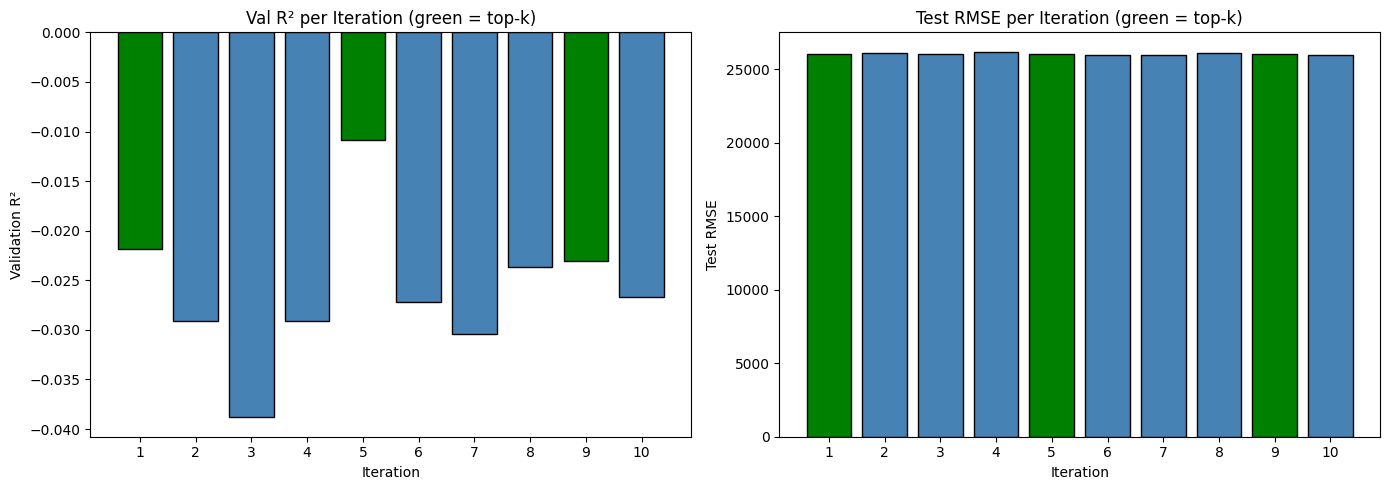

In [30]:
# ── Iteration Performance Visualization ──
iterations = [r["iteration"] + 1 for r in all_results]
val_r2s = [r["val_r2"] for r in all_results]
test_rmses = [r["test_rmse"] for r in all_results]
colors = ["green" if r["iteration"] in top_indices else "steelblue" for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(iterations, val_r2s, color=colors, edgecolor="black")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Validation R²")
axes[0].set_title("Val R² per Iteration (green = top-k)")
axes[0].set_xticks(iterations)

axes[1].bar(iterations, test_rmses, color=colors, edgecolor="black")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Test RMSE")
axes[1].set_title("Test RMSE per Iteration (green = top-k)")
axes[1].set_xticks(iterations)

plt.tight_layout()
plt.show()